Importing required libraries for to load and train data

In [1]:
import pandas as pd
import numpy as np
import pickle
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline

Data Load

In [2]:
df=pd.read_csv("data.csv")

In [3]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [4]:
df["city"].unique()

array(['Shoreline', 'Seattle', 'Kent', 'Bellevue', 'Redmond',
       'Maple Valley', 'North Bend', 'Lake Forest Park', 'Sammamish',
       'Auburn', 'Des Moines', 'Bothell', 'Federal Way', 'Kirkland',
       'Issaquah', 'Woodinville', 'Normandy Park', 'Fall City', 'Renton',
       'Carnation', 'Snoqualmie', 'Duvall', 'Burien', 'Covington',
       'Inglewood-Finn Hill', 'Kenmore', 'Newcastle', 'Mercer Island',
       'Black Diamond', 'Ravensdale', 'Clyde Hill', 'Algona', 'Skykomish',
       'Tukwila', 'Vashon', 'Yarrow Point', 'SeaTac', 'Medina',
       'Enumclaw', 'Snoqualmie Pass', 'Pacific', 'Beaux Arts Village',
       'Preston', 'Milton'], dtype=object)

EDA for the above data set

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
df.isna().sum() #not contain any null values

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [8]:
#How many houses are there in total?
df.shape

(4600, 18)

In [9]:
#What is the range (min, max) and average of house prices?
min_price=df["price"].min()
max_price=df["price"].max()
avg_price=df["price"].mean()

print(f"minimum house price is : {min_price}")
print(f"maximum house price is : {max_price}")
print(f"average house price is : {avg_price}")

minimum house price is : 0.0
maximum house price is : 26590000.0
average house price is : 551962.9884732141


In [10]:
#Which cities have the highest and lowest average prices?
avg_price_by_city = df.groupby("city")["price"].mean().sort_values(ascending=False)

highest_avg_city = avg_price_by_city.idxmax()
highest_avg_price = avg_price_by_city.max()

lowest_avg_city = avg_price_by_city.idxmin()
lowest_avg_price = avg_price_by_city.min()

print(f"City with highest average price: {highest_avg_city} (${highest_avg_price:,.0f})")
print(f"City with lowest average price: {lowest_avg_city} (${lowest_avg_price:,.0f})")

City with highest average price: Medina ($2,046,559)
City with lowest average price: Algona ($207,288)


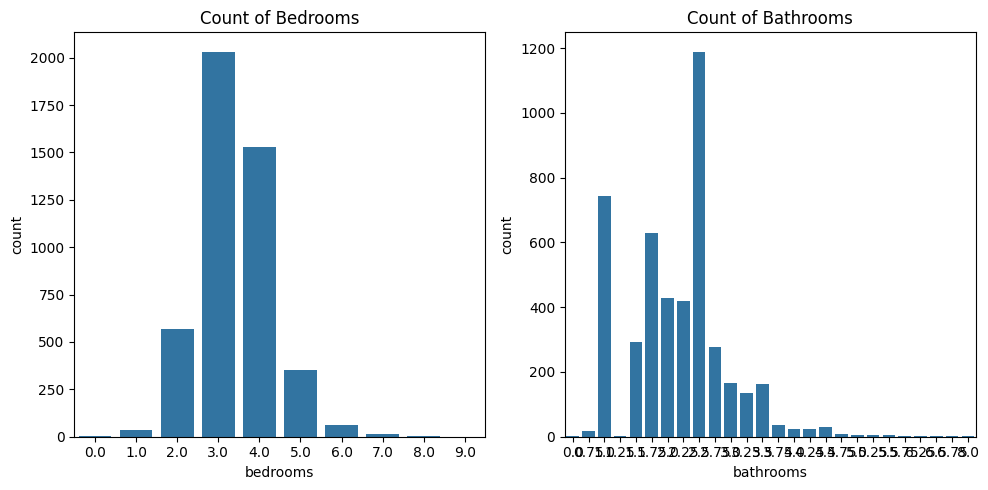

In [11]:
#How are houses distributed by number of bedrooms and bathrooms?

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x='bedrooms', data=df, ax=axes[0])
axes[0].set_title('Count of Bedrooms')


sns.countplot(x='bathrooms', data=df, ax=axes[1])
axes[1].set_title('Count of Bathrooms')

plt.tight_layout()

plt.show()

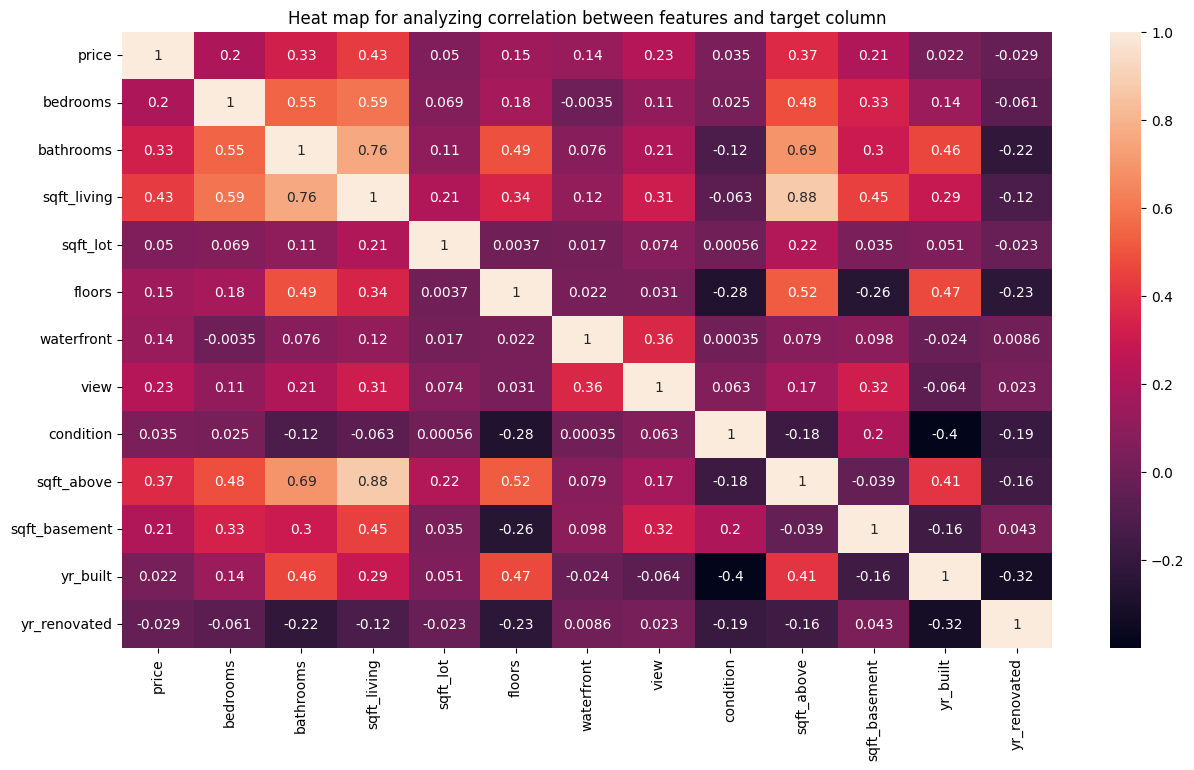

In [12]:
#What features (bedrooms, bathrooms, sqft_living, floors, waterfront, view, etc.) have the strongest correlation with price?

plt.figure(figsize=(15,8))
numeric_ol=df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_ol.corr(),annot=True)
plt.title("Heat map for analyzing correlation between features and target column")
plt.show()

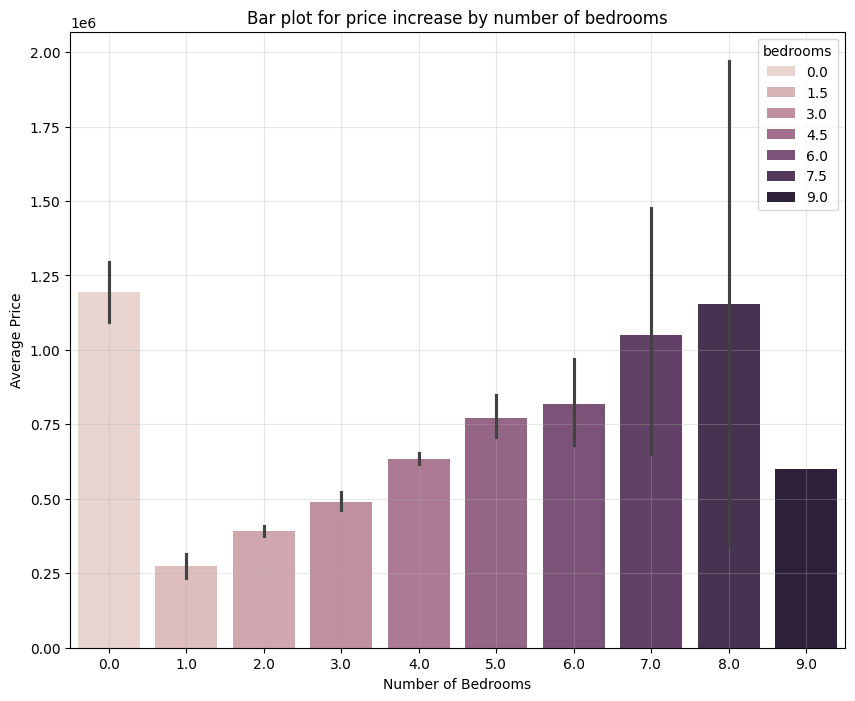

In [13]:
#How does the price vary by number of bedrooms?

plt.figure(figsize=(10,8))
plt.title("Bar plot for price increase by number of bedrooms")
sns.barplot(data=df,x="bedrooms",y="price",hue="bedrooms")
plt.grid(alpha=0.3)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.show()

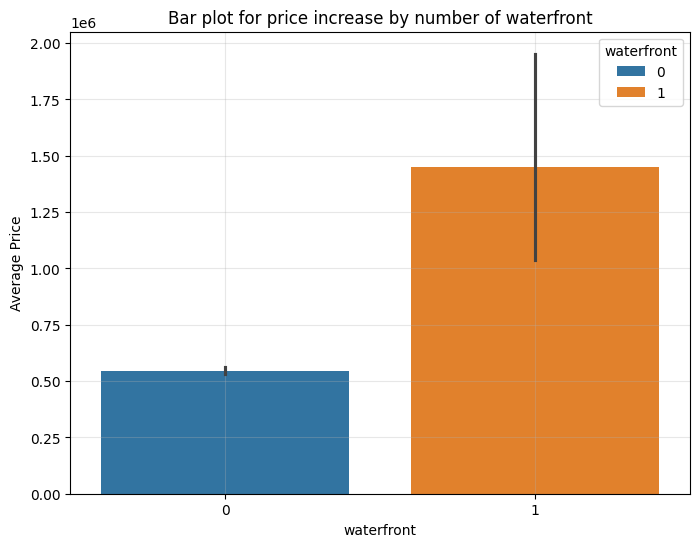

In [14]:
#Do waterfront properties have a significantly higher price?
plt.figure(figsize=(8,6))
plt.title("Bar plot for price increase by number of waterfront")
sns.barplot(data=df,x="waterfront",y="price",hue="waterfront")
plt.grid(alpha=0.3)
plt.xlabel("waterfront")
plt.ylabel("Average Price")
plt.show()

<Figure size 1500x1200 with 0 Axes>

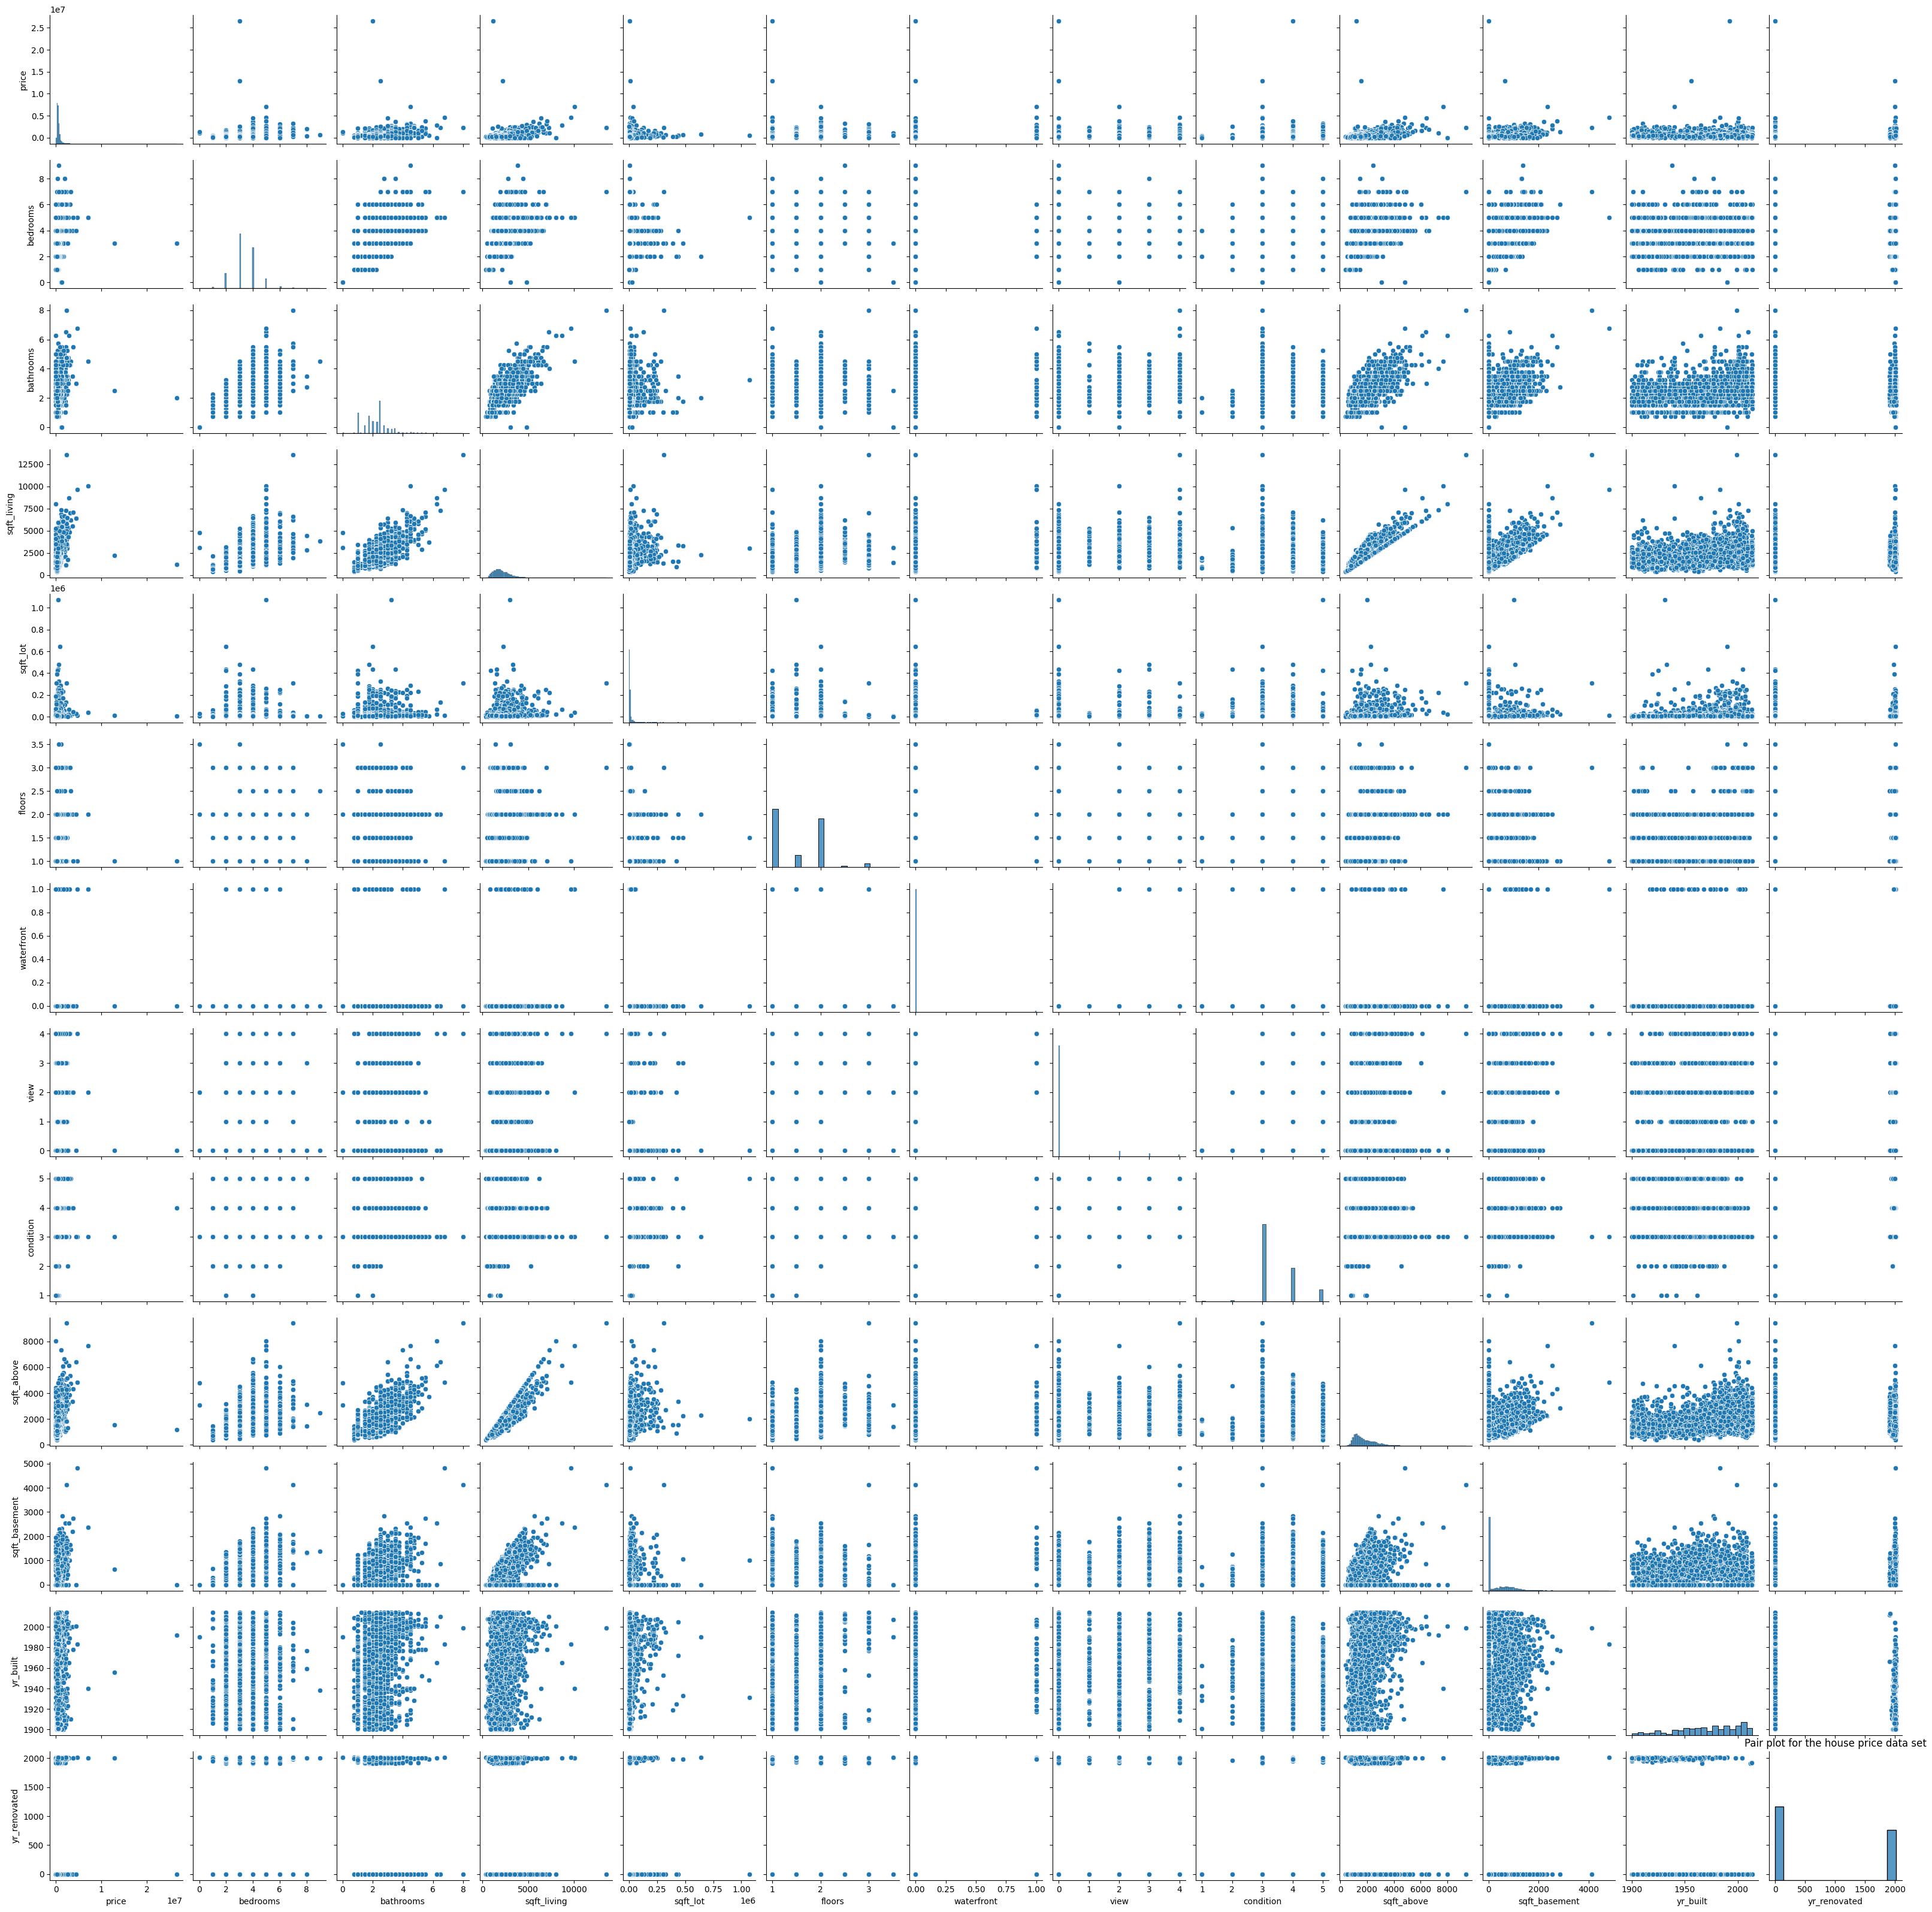

In [15]:
#Pair plot

plt.figure(figsize=(15,12))
sns.pairplot(df)
plt.title("Pair plot for the house price data set")
plt.show()

Data Preprocessing 

In [16]:
#Drop the rows where the house price=0.0

df=df[df["price"]!=0]
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [17]:
#Drop Duplicates
df=df.drop_duplicates()

In [18]:
# Converting date column
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

In [19]:
# Price per sqft
df["price_per_sqft"] = df["price"] / df["sqft_living"]

# Age of house at sale
df["age_at_sale"] = df["sale_year"] - df["yr_built"]

# Renovation flags
df["was_renovated"] = np.where(df["yr_renovated"] > 0, 1, 0)
df["years_since_reno"] = np.where(df["yr_renovated"] > 0, df["sale_year"] - df["yr_renovated"], df["sale_year"] - df["yr_built"])


In [20]:
for col in ["price", "price_per_sqft", "sqft_living"]:
    low, high = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=low, upper=high)


In [21]:
#dropping unused columns
df=df.drop(columns=["date", "street", "statezip", "country"],axis=1)

In [22]:
df["price"] = np.log1p(df["price"])

In [23]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,sale_year,sale_month,price_per_sqft,age_at_sale,was_renovated,years_since_reno
0,12.653962,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,233.582090,59,1,9
1,14.516626,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,2014,5,618.500911,93,0,93
2,12.742569,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5,177.202073,48,0,48
3,12.948012,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,2014,5,210.000000,51,0,51
4,13.217675,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,2014,5,283.505155,38,1,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,12.638399,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,2014,7,204.083885,60,1,35
4596,13.188777,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,2014,7,365.981735,31,1,5
4597,12.940614,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,2014,7,138.506368,5,0,5
4598,12.222935,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,2014,7,98.121921,40,0,40


In [24]:
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=["price"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric cols:", numeric_features)
print("Categorical cols:", categorical_features)

Numeric cols: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sale_year', 'sale_month', 'price_per_sqft', 'age_at_sale', 'was_renovated', 'years_since_reno']
Categorical cols: ['city']


In [25]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [26]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,sale_year,sale_month,price_per_sqft,age_at_sale,was_renovated,years_since_reno
0,12.653962,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,233.582090,59,1,9
1,14.516626,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,2014,5,618.500911,93,0,93
2,12.742569,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5,177.202073,48,0,48
3,12.948012,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,2014,5,210.000000,51,0,51
4,13.217675,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,2014,5,283.505155,38,1,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,12.638399,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,2014,7,204.083885,60,1,35
4596,13.188777,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,2014,7,365.981735,31,1,5
4597,12.940614,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,2014,7,138.506368,5,0,5
4598,12.222935,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,2014,7,98.121921,40,0,40


In [27]:
#for input
x=df.drop(columns=["price","city"],axis=1)

#for output
y=df["price"]

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}


In [30]:
best_model_name = None
best_score = -np.inf
best_pipeline = None

In [31]:
from sklearn.pipeline import Pipeline

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_score = -np.inf   # since higher R² is better
best_model_name = None
best_pipeline = None

for name, reg in models.items():
    pipeline = Pipeline(steps=[
        ("regressor", reg)
    ])

    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 {name} Results:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")

    # Use R² to pick best (higher is better)
    if r2 > best_score:
        best_score = r2
        best_model_name = name
        best_pipeline = pipeline

print(f"\n🏆 Best Model: {best_model_name} (R² = {best_score:.4f})")



📊 Decision Tree Results:
MAE: 0.0333
MSE: 0.0047
R²: 0.9832

📊 Random Forest Results:
MAE: 0.0149
MSE: 0.0021
R²: 0.9925

📊 AdaBoost Results:
MAE: 0.1227
MSE: 0.0264
R²: 0.9048

📊 XGBoost Results:
MAE: 0.0235
MSE: 0.0026
R²: 0.9907

📊 CatBoost Results:
MAE: 0.0135
MSE: 0.0019
R²: 0.9931

🏆 Best Model: CatBoost (R² = 0.9931)


In [33]:
import joblib

#Saving Best Model
model_filename = "house_price_best_model.pkl"

#Using joblib.dump() to save the best_pipeline
joblib.dump(best_pipeline, model_filename)

print(f"\n✅ Best Model: {best_model_name} (Accuracy = {best_score:.4f}) saved as {model_filename}")


✅ Best Model: CatBoost (Accuracy = 0.9931) saved as house_price_best_model.pkl
